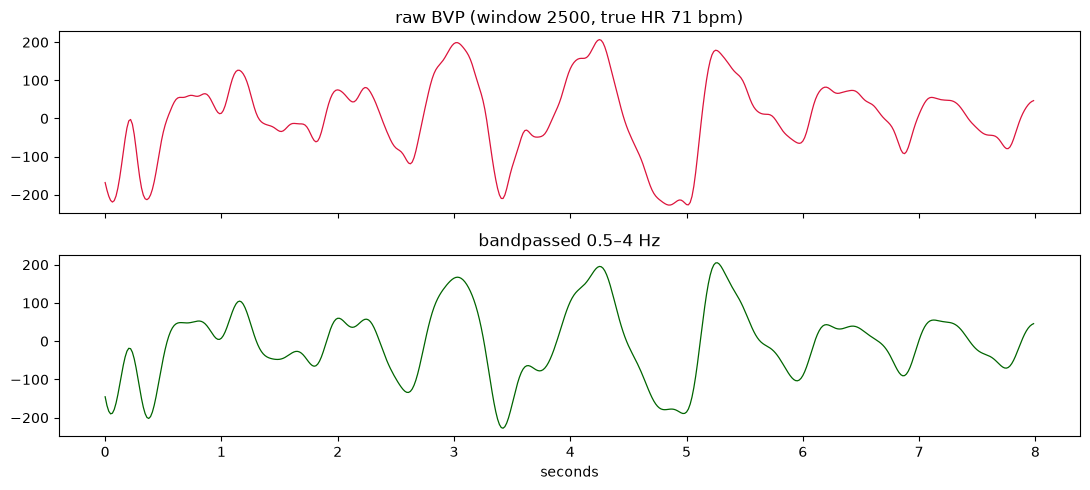

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch

from ppghr.io import load_subject, wrist_streams, window_slice, FS_BVP, FS_ACC, FS_ACT, ACTIVITIES

s1 = load_subject(1)
bvp, acc, labels, activity = wrist_streams(s1)

def bandpass(x, fs, low=0.5, high=4.0, order=3):
    nyq = fs / 2
    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, x)

bvp_f = bandpass(bvp, FS_BVP)

i = 2500
raw = window_slice(i, bvp, FS_BVP)
filt = window_slice(i, bvp_f, FS_BVP)
t = np.arange(len(raw)) / FS_BVP

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].plot(t, raw, lw=0.9, color="crimson")
axes[0].set_title(f"raw BVP (window {i}, true HR {labels[i]:.0f} bpm)")
axes[1].plot(t, filt, lw=0.9, color="darkgreen")
axes[1].set_title("bandpassed 0.5–4 Hz")
axes[1].set_xlabel("seconds")
plt.tight_layout()
plt.show()

In [2]:
print(f"raw   mean {bvp.mean():.3f}   std {bvp.std():.1f}")
print(f"filt  mean {bvp_f.mean():.3f}   std {bvp_f.std():.1f}")
print(f"correlation: {np.corrcoef(bvp, bvp_f)[0,1]:.4f}")

raw   mean -0.002   std 97.1
filt  mean -0.001   std 87.5
correlation: 0.9453


In [3]:
low = bandpass(bvp, FS_BVP, low=0.05, high=0.5)
high = bandpass(bvp, FS_BVP, low=4.0, high=31.0)

total_p = bvp.var()
print(f"below 0.5 Hz: {low.var()/total_p*100:5.1f}% of power")
print(f"above 4 Hz:   {high.var()/total_p*100:5.1f}% of power")
print(f"0.5–4 Hz:     {bvp_f.var()/total_p*100:5.1f}% of power")

below 0.5 Hz:  10.1% of power
above 4 Hz:     1.1% of power
0.5–4 Hz:      81.2% of power


In [4]:
def spectrum(x, fs, nfft=2048):
    f, p = welch(x, fs=fs, nperseg=len(x), nfft=nfft, detrend="constant")
    return f, p

def hr_argmax(window, fs, lo=0.5, hi=3.5):
    """Naive estimate: strongest spectral peak in the HR band."""
    f, p = spectrum(window, fs)
    band = (f >= lo) & (f <= hi)
    return f[band][np.argmax(p[band])] * 60

In [5]:
est_argmax = np.array([hr_argmax(window_slice(i, bvp_f, FS_BVP), FS_BVP)
                       for i in range(len(labels))])

err = np.abs(est_argmax - labels)
print(f"overall MAE: {err.mean():.2f} bpm")
print(f"median AE:   {np.median(err):.2f} bpm\n")

win_act = np.array([
    (lambda v: -1 if len(v) > 1 else int(v[0]))(np.unique(window_slice(i, activity, FS_ACT)))
    for i in range(len(labels))
])

for code in sorted(set(win_act.tolist())):
    if code < 0:
        continue
    m = win_act == code
    print(f"{ACTIVITIES[code]:14s} n={m.sum():5d}   MAE {err[m].mean():6.2f} bpm")

overall MAE: 11.67 bpm
median AE:   4.28 bpm

transient      n= 1113   MAE  15.28 bpm
sitting        n=  347   MAE   3.62 bpm
stairs         n=  140   MAE  32.21 bpm
table_soccer   n=  169   MAE  16.54 bpm
cycling        n=  203   MAE  15.25 bpm
driving        n=  441   MAE   7.71 bpm
lunch          n= 1174   MAE   8.55 bpm
walking        n=  373   MAE  20.61 bpm
working        n=  591   MAE   4.45 bpm


In [6]:
signed = est_argmax - labels

for code in [1, 7, 2, 4]:
    m = win_act == code
    s = signed[m]
    over = (s > 10).sum()
    under = (s < -10).sum()
    print(f"{ACTIVITIES[code]:14s} mean signed {s.mean():+7.2f}   "
          f"over by >10: {over/m.sum()*100:4.1f}%   under by >10: {under/m.sum()*100:4.1f}%")

sitting        mean signed   +0.79   over by >10:  6.9%   under by >10:  4.0%
walking        mean signed   -5.91   over by >10: 27.6%   under by >10: 37.3%
stairs         mean signed  -30.67   over by >10:  2.9%   under by >10: 81.4%
cycling        mean signed  -14.13   over by >10:  1.0%   under by >10: 28.6%


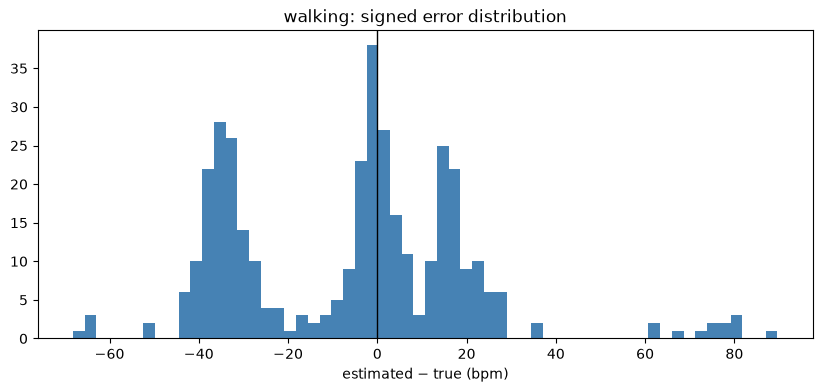

In [7]:
m = win_act == 7
plt.figure(figsize=(10, 4))
plt.hist(signed[m], bins=60, color="steelblue")
plt.axvline(0, color="black", lw=1)
plt.xlabel("estimated − true (bpm)")
plt.title("walking: signed error distribution")
plt.show()

In [8]:
from ppghr.io import FS_ACC

def acc_peak_hz(i, lo=0.3, hi=3.5):
    a = window_slice(i, acc, FS_ACC)
    mag = bandpass(np.linalg.norm(a, axis=1), FS_ACC, 0.3, 4.0)
    f, p = spectrum(mag, FS_ACC)
    band = (f >= lo) & (f <= hi)
    return f[band][np.argmax(p[band])] * 60

fail = np.where((win_act == 7) & (np.abs(signed) > 15))[0]

print(f"{'true':>6} {'est':>6} {'acc_peak':>9} {'|est-acc|':>10}")
for i in fail[:15]:
    a_bpm = acc_peak_hz(i)
    print(f"{labels[i]:6.0f} {est_argmax[i]:6.0f} {a_bpm:9.0f} {abs(est_argmax[i]-a_bpm):10.0f}")

gaps = np.array([abs(est_argmax[i] - acc_peak_hz(i)) for i in fail])
print(f"\nfailing windows where estimate is within 5 bpm of an ACC peak: "
      f"{(gaps < 5).mean()*100:.0f}%")

  true    est  acc_peak  |est-acc|
    78     36        79         43
    88     52        57          5
    77     41       101         60
    79     43       105         62
    86     68       109         41
    76     45        80         35
    77     47        75         28
    81     54        73         19
    82    159        53        106
    84    107       103          4
    80    101        98          3
    76     96        95          1
    80     47        86         39
    81     51        83         33
    79    107        92         15

failing windows where estimate is within 5 bpm of an ACC peak: 32%


In [9]:
def acc_peaks_hz(i, lo=0.3, hi=3.5, n=3):
    """Top motion frequencies from each ACC axis separately, in bpm."""
    a = window_slice(i, acc, FS_ACC)
    out = []
    for ax in range(3):
        sig = bandpass(a[:, ax], FS_ACC, 0.3, 4.0)
        f, p = spectrum(sig, FS_ACC)
        band = (f >= lo) & (f <= hi)
        fb, pb = f[band], p[band]
        for idx in np.argsort(pb)[-n:]:
            out.append(fb[idx] * 60)
    return np.array(out)

def matches_motion(est, peaks, tol=6):
    """Does est sit near a motion peak, or its half or double?"""
    cands = np.concatenate([peaks, peaks / 2, peaks * 2])
    return np.min(np.abs(cands - est)) < tol

hits = np.array([matches_motion(est_argmax[i], acc_peaks_hz(i)) for i in fail])
print(f"failures explained by a motion frequency or harmonic: {hits.mean()*100:.0f}%")

ok = np.where((win_act == 7) & (np.abs(signed) <= 5))[0][:len(fail)]
hits_ok = np.array([matches_motion(est_argmax[i], acc_peaks_hz(i)) for i in ok])
print(f"same test on CORRECT windows (false positive rate): {hits_ok.mean()*100:.0f}%")

failures explained by a motion frequency or harmonic: 85%
same test on CORRECT windows (false positive rate): 11%


In [10]:
def hr_tracked(i, prev_hr, lo=0.5, hi=3.5,
               motion_penalty=0.4, tol=6.0, continuity_sigma=12.0):
    """Spectral peak with ACC-based suppression and temporal continuity."""
    f, p = spectrum(window_slice(i, bvp_f, FS_BVP), FS_BVP)
    band = (f >= lo) & (f <= hi)
    fb, pb = f[band] * 60, p[band].copy()

    peaks = acc_peaks_hz(i)
    cands = np.concatenate([peaks, peaks / 2, peaks * 2])
    near_motion = np.min(np.abs(fb[:, None] - cands[None, :]), axis=1) < tol
    pb[near_motion] *= motion_penalty

    if prev_hr is not None:
        pb = pb * np.exp(-0.5 * ((fb - prev_hr) / continuity_sigma) ** 2)

    return fb[np.argmax(pb)]

In [11]:
est_tracked = np.zeros(len(labels))
prev = None
for i in range(len(labels)):
    prev = hr_tracked(i, prev)
    est_tracked[i] = prev

err_t = np.abs(est_tracked - labels)
print(f"argmax   MAE {np.abs(est_argmax - labels).mean():6.2f}   median {np.median(np.abs(est_argmax-labels)):5.2f}")
print(f"tracked  MAE {err_t.mean():6.2f}   median {np.median(err_t):5.2f}\n")

for code in sorted(set(win_act.tolist())):
    if code < 0:
        continue
    m = win_act == code
    print(f"{ACTIVITIES[code]:14s} {np.abs(est_argmax-labels)[m].mean():7.2f} → {err_t[m].mean():6.2f}")

argmax   MAE  11.67   median  4.28
tracked  MAE  11.69   median  4.15

transient        15.28 →  11.64
sitting           3.62 →   4.35
stairs           32.21 →  38.73
table_soccer     16.54 →  15.12
cycling          15.25 →   5.59
driving           7.71 →  11.46
lunch             8.55 →   7.25
walking          20.61 →  36.59
working           4.45 →   3.60


In [12]:
def hr_penalty_only(i, lo=0.5, hi=3.5, motion_penalty=0.4, tol=6.0):
    f, p = spectrum(window_slice(i, bvp_f, FS_BVP), FS_BVP)
    band = (f >= lo) & (f <= hi)
    fb, pb = f[band] * 60, p[band].copy()
    cands = np.concatenate([(pk := acc_peaks_hz(i)), pk / 2, pk * 2])
    near = np.min(np.abs(fb[:, None] - cands[None, :]), axis=1) < tol
    pb[near] *= motion_penalty
    return fb[np.argmax(pb)]

est_pen = np.array([hr_penalty_only(i) for i in range(len(labels))])
err_p = np.abs(est_pen - labels)

print(f"argmax        MAE {np.abs(est_argmax-labels).mean():6.2f}")
print(f"penalty only  MAE {err_p.mean():6.2f}")
print(f"penalty+track MAE {err_t.mean():6.2f}\n")

for code in sorted(set(win_act.tolist())):
    if code < 0:
        continue
    m = win_act == code
    print(f"{ACTIVITIES[code]:14s} {np.abs(est_argmax-labels)[m].mean():7.2f} → "
          f"{err_p[m].mean():7.2f} → {err_t[m].mean():7.2f}")

argmax        MAE  11.67
penalty only  MAE  11.75
penalty+track MAE  11.69

transient        15.28 →   15.06 →   11.64
sitting           3.62 →    4.26 →    4.35
stairs           32.21 →   33.42 →   38.73
table_soccer     16.54 →   17.14 →   15.12
cycling          15.25 →   12.37 →    5.59
driving           7.71 →    8.13 →   11.46
lunch             8.55 →    9.52 →    7.25
walking          20.61 →   18.47 →   36.59
working           4.45 →    5.02 →    3.60


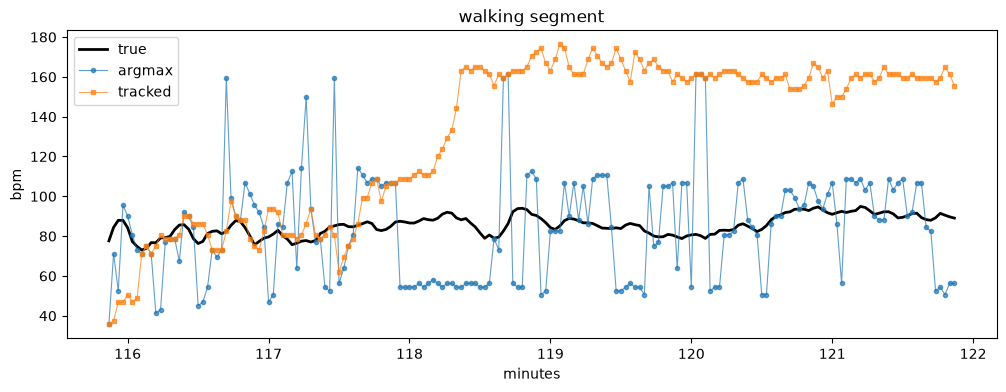

In [13]:
seg = np.where(win_act == 7)[0]
seg = seg[(seg >= seg[0]) & (seg <= seg[0] + 180)]

plt.figure(figsize=(12, 4))
plt.plot(seg * 2 / 60, labels[seg], "k-", lw=2, label="true")
plt.plot(seg * 2 / 60, est_argmax[seg], "o-", ms=3, lw=0.8, alpha=0.7, label="argmax")
plt.plot(seg * 2 / 60, est_tracked[seg], "s-", ms=3, lw=0.8, alpha=0.7, label="tracked")
plt.xlabel("minutes")
plt.ylabel("bpm")
plt.legend()
plt.title("walking segment")
plt.show()

In [14]:
def hr_tracked_v2(lo=0.5, hi=3.5, motion_penalty=0.5, tol=6.0,
                  sigma=20.0, prior_floor=0.15, max_jump=15.0):
    est = np.zeros(len(labels))
    prev = None
    for i in range(len(labels)):
        f, p = spectrum(window_slice(i, bvp_f, FS_BVP), FS_BVP)
        band = (f >= lo) & (f <= hi)
        fb, pb = f[band] * 60, p[band].copy()

        pk = acc_peaks_hz(i)
        cands = np.concatenate([pk, pk / 2, pk * 2])
        near = np.min(np.abs(fb[:, None] - cands[None, :]), axis=1) < tol
        pb[near] *= motion_penalty

        if prev is not None:
            w = np.exp(-0.5 * ((fb - prev) / sigma) ** 2)
            pb = pb * np.maximum(w, prior_floor)

        pick = fb[np.argmax(pb)]
        if prev is not None:
            pick = np.clip(pick, prev - max_jump, prev + max_jump)
        est[i] = prev = pick
    return est

est_v2 = hr_tracked_v2()
err_v2 = np.abs(est_v2 - labels)
print(f"argmax {np.abs(est_argmax-labels).mean():6.2f}   v1 {err_t.mean():6.2f}   v2 {err_v2.mean():6.2f}\n")
for code in sorted(set(win_act.tolist())):
    if code < 0: continue
    m = win_act == code
    print(f"{ACTIVITIES[code]:14s} {np.abs(est_argmax-labels)[m].mean():7.2f} → {err_v2[m].mean():7.2f}")

argmax  11.67   v1  11.69   v2   9.10

transient        15.28 →   11.67
sitting           3.62 →    3.41
stairs           32.21 →   30.89
table_soccer     16.54 →   15.66
cycling          15.25 →   12.03
driving           7.71 →    7.93
lunch             8.55 →    7.32
walking          20.61 →    7.99
working           4.45 →    3.94
